### Create synthetic dataset

In [1]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

#### Necessary imports

In [10]:
from itertools import permutations
for i, j in permutations(range(1, 3), 2):
    print(i, j)

import torch
idx = torch.triu_indices(3, 3, offset=1)  # (2, P)
i = idx[0]
j = idx[1]
print(i, j)

1 2
2 1
tensor([0, 0, 1]) tensor([1, 2, 2])


In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.utils.helpers import linear_probe, extract_latents_and_labels, plot_confusion_matrix


In [21]:
N_data = 100
M = 3  # number of modalities
ts = [5, 5, 5]  # time steps for each modality
gammas = [1.5, 1.5, 1.5]  # gamma parameters for each modality
trans_type = "identity"
latent_dim = 2
dist = "vmf"
sigma = 0.5
normalize = True

In [22]:
gen_data = GenerateData(N_data= N_data, trans_type= trans_type, latent_dim= latent_dim, M= M)
gen_data.create_dataset(dist= dist, ts= ts, gammas= gammas, sigma= sigma, normalize= normalize)
gen_data.print_dataset_info()
dataset = MultimodalDataset(total_data= gen_data.dataset_dict['total_data'], labels_u= gen_data.dataset_dict['labels_u'], labels_s= gen_data.dataset_dict['labels_s'])

Dataset Information:
Number of samples: 100
Number of modalities: 3
Modality 1 data shape: (5, 8)
Modality 2 data shape: (5, 8)
Modality 3 data shape: (5, 8)
Labels for unique component u_12 shape: (100,)
Labels for unique component u_13 shape: (100,)
Labels for unique component u_21 shape: (100,)
Labels for unique component u_23 shape: (100,)
Labels for unique component u_31 shape: (100,)
Labels for unique component u_32 shape: (100,)
Labels for shared component s_12 shape: (100,)
Labels for shared component s_13 shape: (100,)
Labels for shared component s_23 shape: (100,)
Latent factors for unique component u_12 shape: (100, 4)
Latent factors for unique component u_13 shape: (100, 4)
Latent factors for unique component u_21 shape: (100, 4)
Latent factors for unique component u_23 shape: (100, 4)
Latent factors for unique component u_31 shape: (100, 4)
Latent factors for unique component u_32 shape: (100, 4)
Latent factors for shared component s_12 shape: (100, 4)
Latent factors for s

### Check Data creation

In [26]:
dataset.__getitem__(0)
dataloader = DataLoader(dataset, batch_size= 16, shuffle= True)
for (m1, m2, m3), u, s in dataloader:
    print(m1.shape, m2.shape, m3.shape)
    print(u)
    print(s)
    break


torch.Size([16, 5, 8]) torch.Size([16, 5, 8]) torch.Size([16, 5, 8])
{'u_12': tensor([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1]), 'u_13': tensor([0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1]), 'u_21': tensor([1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0]), 'u_23': tensor([0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0]), 'u_31': tensor([0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1]), 'u_32': tensor([1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0])}
{'s_12': tensor([1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]), 's_13': tensor([0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0]), 's_23': tensor([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0])}


In [24]:
import torch

# Normal
a = torch.normal(0.5, 1.0, size=(1,3))
b = torch.normal(2.0, 1.0, size=(1,3))
c = torch.cat((a, b), dim= -1)
print(f"a sample: {a}, b : {b}, c: {c}, normalized c: {c / torch.norm(c, dim=-1, keepdim=True)}")

a sample: tensor([[-2.1845,  0.3015,  0.6155]]), b : tensor([[1.2801, 2.5442, 2.3765]]), c: tensor([[-2.1845,  0.3015,  0.6155,  1.2801,  2.5442,  2.3765]]), normalized c: tensor([[-0.5011,  0.0692,  0.1412,  0.2937,  0.5837,  0.5452]])


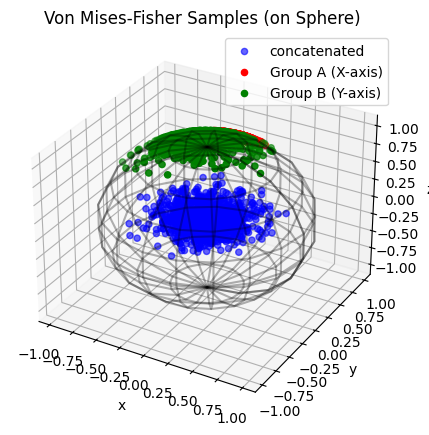

In [27]:
from scipy.stats import vonmises_fisher, multivariate_normal
import numpy as np
import matplotlib.pyplot as plt
# 1. Define directions (Mean vectors on the sphere)
# Must be unit vectors!
loc_a = torch.randn(3) # Points along X
loc_a = loc_a / torch.norm(loc_a)
loc_b = torch.randn(3) # Points along Y
loc_b = loc_b / torch.norm(loc_b)


# 2. Define concentration (kappa)
# Higher = tighter cluster
k_a, k_b = 150.0, 20.0 

# 3. Sample using Scipy
# vonmises_fisher(mu, kappa).rvs(n) returns (n, 3) coordinates
n_samples = 1000
a_samples_np = vonmises_fisher(loc_a, k_a).rvs(n_samples)
b_samples_np = vonmises_fisher(loc_b, k_b).rvs(n_samples)

# Convert to tensor if needed for your pipeline
a_samples = torch.from_numpy(a_samples_np).float()
b_samples = torch.from_numpy(b_samples_np).float()
c = torch.cat((a_samples, b_samples), dim= -1).numpy()

# project c to three dimensions using PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
c = pca.fit_transform(c)

# 4. Plot
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

# Draw the unit sphere wireframe for reference
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax.plot_wireframe(x, y, z, color="k", alpha=0.3)
ax.scatter(c[:, 0], c[:, 1], c[:, 2], alpha=0.6, label='concatenated', color='b')
ax.scatter(a_samples[:, 0], a_samples[:, 1], a_samples[:, 2], color='r', label='Group A (X-axis)')
ax.scatter(b_samples[:, 0], b_samples[:, 1], b_samples[:, 2], color='g', label='Group B (Y-axis)')

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Von Mises-Fisher Samples (on Sphere)")
plt.show()


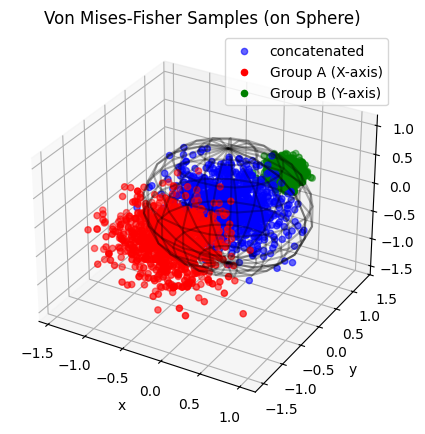

In [ ]:
a_mean = torch.zeros(3) - 0.5
b_mean = torch.zeros(3) + 0.5
a_cov = torch.eye(3) * 0.1
b_cov = torch.eye(3) * 0.01

# vonmises_fisher(mu, kappa).rvs(n) returns (n, 3) coordinates
n_samples = 1000
a_samples_np = multivariate_normal(mean=a_mean.numpy(), cov=a_cov.numpy()).rvs(n_samples)
b_samples_np = multivariate_normal(mean=b_mean.numpy(), cov=b_cov.numpy()).rvs(n_samples)

# Convert to tensor if needed for your pipeline
a_samples = torch.from_numpy(a_samples_np).float()
b_samples = torch.from_numpy(b_samples_np).float()
c = torch.cat((a_samples, b_samples), dim= -1).numpy()

# project c to three dimensions using PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
c = pca.fit_transform(c)

# 4. Plot
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

# Draw the unit sphere wireframe for reference
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax.plot_wireframe(x, y, z, color="k", alpha=0.3)

ax.scatter(c[:, 0], c[:, 1], c[:, 2], alpha=0.6, label='concatenated', color='b')
ax.scatter(a_samples[:, 0], a_samples[:, 1], a_samples[:, 2], color='r', label='Group A (X-axis)')
ax.scatter(b_samples[:, 0], b_samples[:, 1], b_samples[:, 2], color='g', label='Group B (Y-axis)')

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Von Mises-Fisher Samples (on Sphere)")
plt.show()

In [ ]:
dataloader = DataLoader(dataset, batch_size= 1, shuffle= True)

for x1, x2, y1, y2, ys in dataloader:
    x1_aug = gen_data.augment_data(x1, aug_type="noise", scale= 1e-3)
    print(f"Original x1: {x1}")
    print(f"Augmented x1: {x1_aug}")
    break

Original x1: tensor([[[ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691]]])
Augmented x1: tensor([[[ 0.3563, -0.0548,  0.1173, -0.1559,  0.1388,  0.2208, -0.1989,
           0.4254, -0.3